# تحلیل عوامل مؤثر بر فروش پذیرندگان
این نوت‌بوک با کدهای ساده و قابل‌تغییر، داده را از سطح تلاش پرداخت به سطح سشن تبدیل می‌کند تا retry باعث دوباره‌شماری فروش نشود.

**تعریف فروش:** مجموع مبلغ سشن‌های موفق (`Verified` یا `Paid`)؛ تراکنش `Reversed` فروش محسوب نمی‌شود. نتایج این تحلیل رابطه آماری هستند و به‌تنهایی رابطه علت و معلولی را اثبات نمی‌کنند.

In [1]:
# اگر کتابخانه‌ها نصب نیستند، فقط یک بار خط زیر را از حالت کامنت خارج و اجرا کنید:
# %pip install pandas seaborn matplotlib


In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
DATA_PATH = Path("other_challenge_data.csv.gz")
assert DATA_PATH.exists(), f"File not found: {DATA_PATH.resolve()}"

## 1) خواندن داده و کنترل کیفیت اولیه

In [3]:
columns = [
    "session_key", "try_seq", "terminal_key", "merchant_key",
    "category_title", "amount", "session_status", "try_status",
    "psp_code", "issuer_bank_code", "created_at", "try_created_at"
]

category_columns = [
    "terminal_key", "merchant_key", "category_title", "session_status",
    "try_status", "psp_code", "issuer_bank_code"
]
dtypes = {name: "category" for name in category_columns}
dtypes.update({"session_key": "int64", "try_seq": "int16", "amount": "int64"})

raw = pd.read_csv(DATA_PATH, usecols=columns, dtype=dtypes, compression="gzip")
raw["created_at"] = pd.to_datetime(raw["created_at"], errors="coerce")
raw["try_created_at"] = pd.to_datetime(raw["try_created_at"], errors="coerce")

quality = pd.Series({
    "rows": len(raw),
    "unique_sessions": raw["session_key"].nunique(),
    "merchants": raw["merchant_key"].nunique(),
    "terminals": raw["terminal_key"].nunique(),
    "duplicate_session_try": raw.duplicated(["session_key", "try_seq"]).sum(),
    "bad_created_at": raw["created_at"].isna().sum(),
    "non_positive_amount": raw["amount"].le(0).sum(),
})
display(quality.to_frame("value"))

,value
rows,2213289
unique_sessions,2062839
merchants,343
terminals,348
duplicate_session_try,0
bad_created_at,0
non_positive_amount,0


## 2) تبدیل تلاش‌ها به یک ردیف برای هر سشن
ابتدا کلید تکراری `session_key + try_seq` حذف می‌شود. سپس ویژگی‌های سشن ساخته می‌شوند. برای PSP و بانک، آخرین تلاش واقعی را نگه می‌داریم.

In [4]:
raw = raw.sort_values(["session_key", "try_seq", "try_created_at"])
attempts = raw.drop_duplicates(["session_key", "try_seq"], keep="first").copy()
attempts["is_success_row"] = attempts["session_status"].isin(["Verified", "Paid"])
attempts["is_reversed_row"] = attempts["session_status"].eq("Reversed")
attempts["is_real_attempt"] = attempts["try_seq"].gt(0) & attempts["try_status"].ne("NoAttempt")

base = attempts.groupby("session_key", observed=True).agg(
    merchant_key=("merchant_key", "first"),
    terminal_key=("terminal_key", "first"),
    category_title=("category_title", "first"),
    amount=("amount", "min"),
    created_at=("created_at", "min"),
    is_success=("is_success_row", "max"),
    is_reversed=("is_reversed_row", "max"),
    attempts_count=("is_real_attempt", "sum"),
).reset_index()

last_try = (attempts.sort_values(["session_key", "try_created_at"])
            .groupby("session_key", observed=True)
            .tail(1)[["session_key", "psp_code", "issuer_bank_code"]]
            .rename(columns={"psp_code": "final_psp", "issuer_bank_code": "final_bank"}))
sessions = base.merge(last_try, on="session_key", how="left")
sessions = sessions[sessions["amount"].gt(0) & sessions["created_at"].notna()].copy()
sessions["is_success"] = sessions["is_success"] & ~sessions["is_reversed"]
sessions["sales"] = sessions["amount"].where(sessions["is_success"], 0)
print(f"Session table: {len(sessions):,} rows")

Session table: 2,062,839 rows


In [5]:
overall = pd.Series({
    "sessions": len(sessions),
    "successful_sessions": sessions["is_success"].sum(),
    "success_rate": sessions["is_success"].mean(),
    "total_sales_irr": sessions["sales"].sum(),
    "average_ticket_irr": sessions.loc[sessions["is_success"], "amount"].mean(),
})
display(overall.to_frame("value"))

,value
sessions,"2,062,839.00"
successful_sessions,"1,034,361.00"
success_rate,0.50
total_sales_irr,"5,282,015,249,477.00"
average_ticket_irr,"5,106,549.12"


## 3) ساخت ویژگی‌های زمانی و مبلغ

In [6]:
sessions["month"] = sessions["created_at"].dt.to_period("M").astype(str)
sessions["weekday"] = sessions["created_at"].dt.day_name()
sessions["hour"] = sessions["created_at"].dt.hour

def get_season(month):
    if month in [12, 1, 2]: return "Winter"
    if month in [3, 4, 5]: return "Spring"
    if month in [6, 7, 8]: return "Summer"
    return "Autumn"

sessions["season"] = sessions["created_at"].dt.month.map(get_season)
sessions["retry_group"] = pd.cut(
    sessions["attempts_count"], bins=[-1, 0, 1, float("inf")],
    labels=["No attempt", "First try", "Retry"]
)
sessions["amount_bucket"] = pd.cut(
    sessions["amount"], bins=[0, 100_000, 1_000_000, 10_000_000, 100_000_000, float("inf")],
    labels=["<100k", "100k-1m", "1m-10m", "10m-100m", "100m+"], right=False
)

## 4) تابع خلاصه‌ساز و تحلیل فصل/ماه

,month,sessions,successful_sessions,success_rate,sales,merchants,avg_ticket
0,2026-01,212804,94132,0.44,596868077460,259,"6,340,756.36"
1,2026-02,332197,161267,0.49,1051901529210,267,"6,522,732.67"
2,2026-03,377214,188685,0.50,469721687868,173,"2,489,449.02"
3,2026-04,345243,187362,0.54,892178225431,202,"4,761,788.55"
4,2026-05,373594,204497,0.55,1054125309465,240,"5,154,722.61"
5,2026-06,421787,198418,0.47,1217220420043,251,"6,134,627.00"


,season,sessions,successful_sessions,success_rate,sales,merchants,avg_ticket
0,Spring,1096051,580544,0.53,2416025222764,280,"4,161,657.38"
1,Summer,421787,198418,0.47,1217220420043,251,"6,134,627.00"
2,Winter,545001,255399,0.47,1648769606670,296,"6,455,661.95"


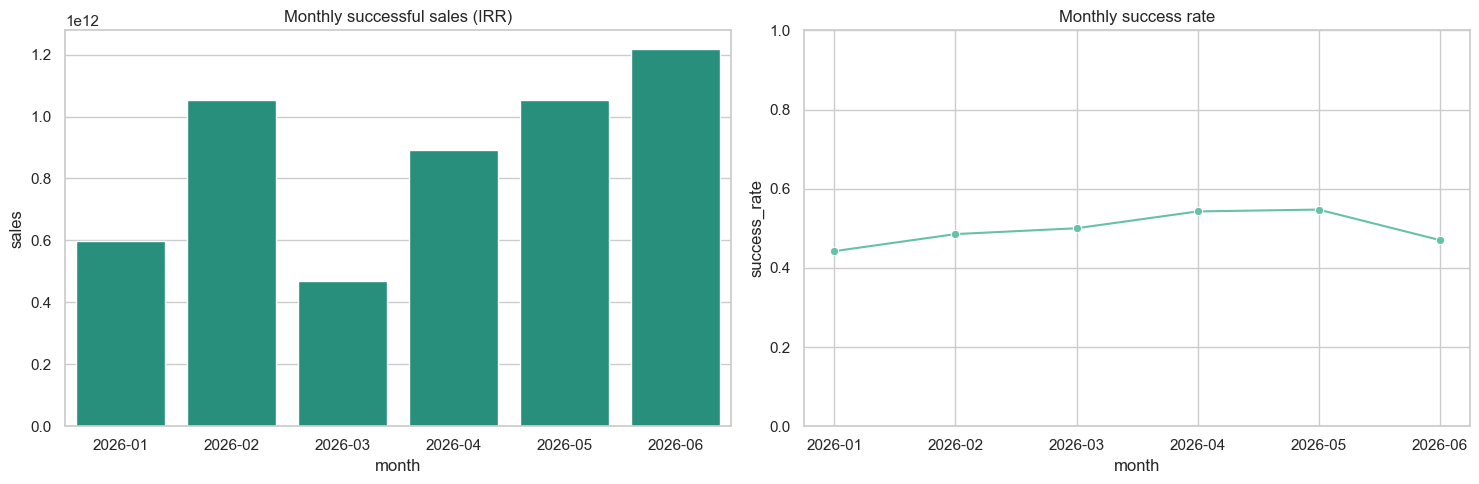

In [7]:
def summarize(data, column):
    result = data.groupby(column, observed=True).agg(
        sessions=("session_key", "size"),
        successful_sessions=("is_success", "sum"),
        success_rate=("is_success", "mean"),
        sales=("sales", "sum"),
        merchants=("merchant_key", "nunique"),
    ).reset_index()
    result["avg_ticket"] = result["sales"] / result["successful_sessions"]
    return result

monthly = summarize(sessions, "month")
seasonal = summarize(sessions, "season")
display(monthly)
display(seasonal)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=monthly, x="month", y="sales", ax=axes[0], color="#16a085")
sns.lineplot(data=monthly, x="month", y="success_rate", marker="o", ax=axes[1])
axes[0].set_title("Monthly successful sales (IRR)")
axes[1].set_title("Monthly success rate")
axes[1].set_ylim(0, 1)
plt.tight_layout();

### نکته مهم درباره فصل
داده فقط از ژانویه تا ژوئن ۲۰۲۶ است؛ تابستان فقط ماه ژوئن را دارد و پاییز اصلاً مشاهده نشده است. بنابراین اختلاف فصل‌ها یک نشانه توصیفی است و برای نتیجه‌گیری قطعی فصلی حداقل دو سال کامل داده لازم است.

## 5) روز هفته و ساعت شبانه‌روز

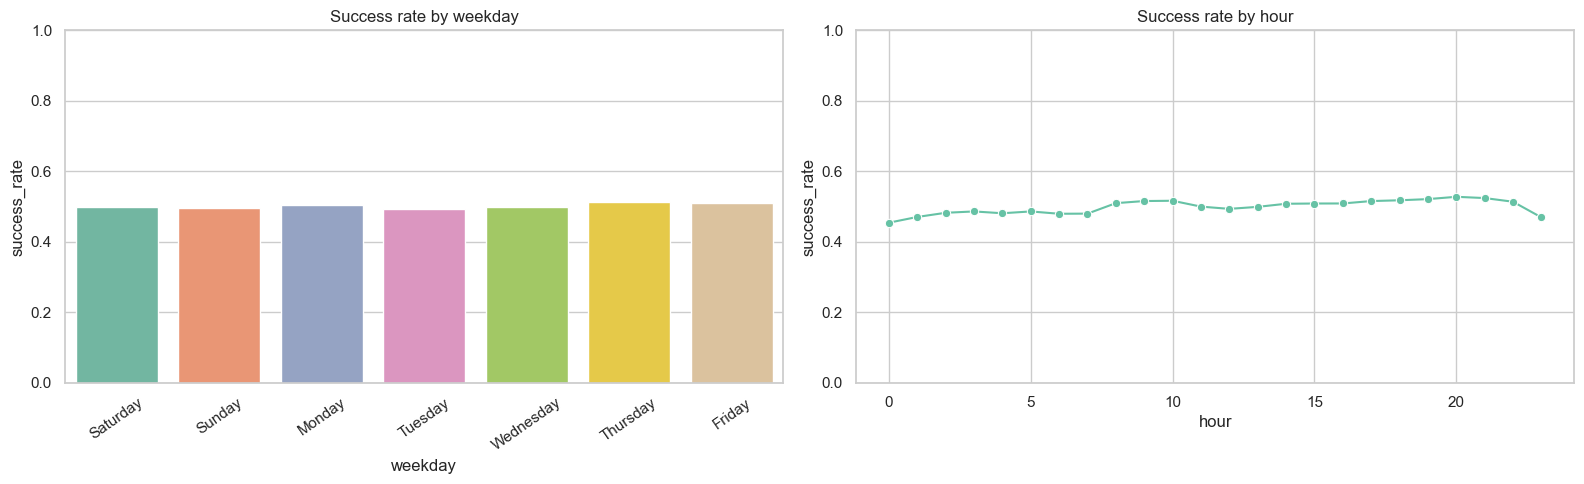

In [8]:
weekday_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
weekday = summarize(sessions, "weekday")
hourly = summarize(sessions, "hour")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=weekday, x="weekday", y="success_rate", order=weekday_order, ax=axes[0])
sns.lineplot(data=hourly, x="hour", y="success_rate", marker="o", ax=axes[1])
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_ylim(0, 1); axes[1].set_ylim(0, 1)
axes[0].set_title("Success rate by weekday")
axes[1].set_title("Success rate by hour")
plt.tight_layout();

## 6) دسته کسب‌وکار، PSP، مبلغ و retry

In [9]:
factors = {
    "Business category": summarize(sessions, "category_title"),
    "PSP": summarize(sessions.assign(final_psp=sessions["final_psp"].astype("string").fillna("NoAttempt")), "final_psp"),
    "Amount bucket": summarize(sessions, "amount_bucket"),
    "Retry": summarize(sessions, "retry_group"),
}
for title, table in factors.items():
    print("\n", title)
    display(table.sort_values("sales", ascending=False))


 Business category


,category_title,sessions,successful_sessions,success_rate,sales,merchants,avg_ticket
2,فروشگاه لوازم آرایشی و بهداشتی,94914,45390,0.48,2246644453030,38,"49,496,462.94"
4,کیف و کفش فروشی,280751,169721,0.60,1704350241596,69,"10,042,070.47"
1,خدمات شبکه‌های کامپیوتری و اینترنت,1285002,705813,0.55,892849961366,53,"1,264,995.06"
0,ارائه دهنده خدمات اینترنت,55606,37317,0.67,247085694061,25,"6,621,263.61"
3,مراکز آموزشی مجازی,346566,76120,0.22,191084899424,158,"2,510,311.34"



 PSP


,final_psp,sessions,successful_sessions,success_rate,sales,merchants,avg_ticket
5,PSP-05,338289,144488,0.43,1884257294504,140,"13,040,925.85"
4,PSP-04,182845,116951,0.64,1698590383072,127,"14,523,949.20"
3,PSP-03,662683,420074,0.63,952766073008,252,"2,268,091.03"
6,PSP-06,55164,36025,0.65,313178152687,161,"8,693,356.08"
1,PSP-01,426169,265685,0.62,304226913380,24,"1,145,066.20"
7,PSP-07,66530,32409,0.49,78108119805,137,"2,410,074.97"
8,PSP-08,64528,16858,0.26,29910203900,15,"1,774,243.91"
2,PSP-02,2695,1871,0.69,20978109121,32,"11,212,244.32"
0,NoAttempt,263936,0,0.00,0,263,NaN



 Amount bucket


,amount_bucket,sessions,successful_sessions,success_rate,sales,merchants,avg_ticket
3,10m-100m,194411,107740,0.55,2640553460701,252,"24,508,571.20"
4,100m+,12164,6484,0.53,1219545351731,120,"188,085,341.11"
2,1m-10m,659289,262914,0.40,1055005297809,288,"4,012,739.14"
1,100k-1m,1169802,642244,0.55,366094453287,170,"570,023.94"
0,<100k,27173,14979,0.55,816685949,179,"54,522.06"



 Retry


,retry_group,sessions,successful_sessions,success_rate,sales,merchants,avg_ticket
1,First try,1724218,992061,0.58,5114238949214,321,"5,155,165.81"
2,Retry,74685,42300,0.57,167776300263,211,"3,966,342.80"
0,No attempt,263936,0,0.00,0,263,NaN


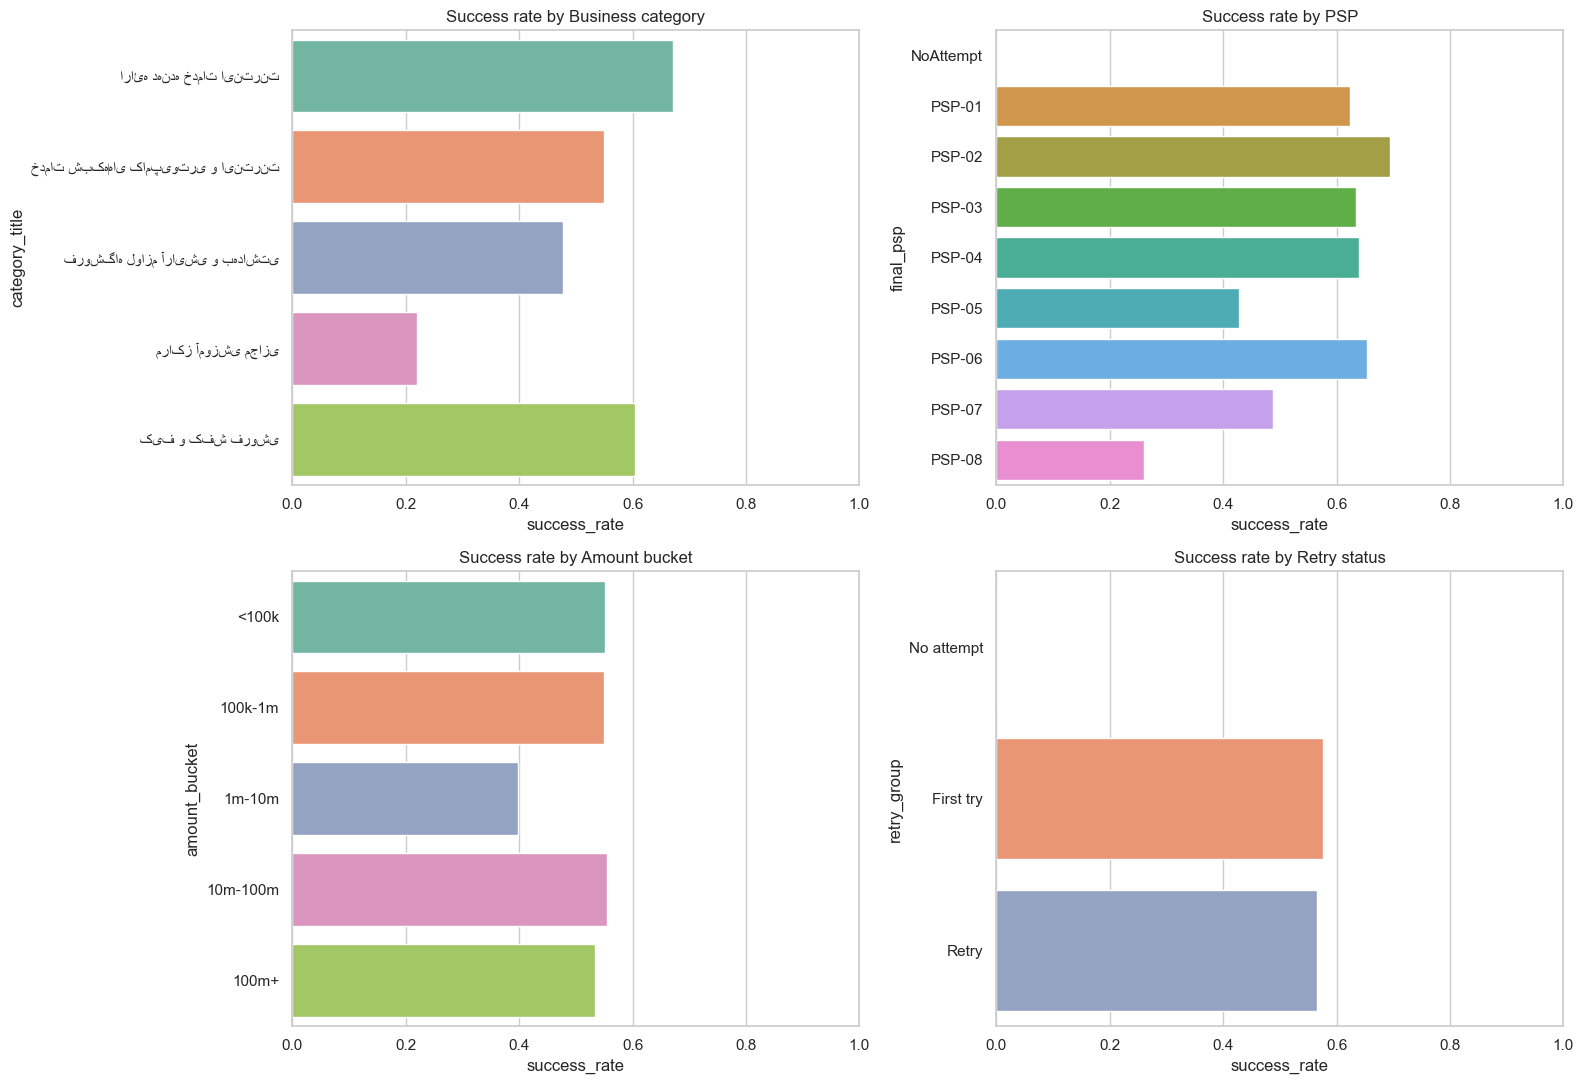

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
plots = [
    (factors["Business category"], "category_title", "Business category"),
    (factors["PSP"], "final_psp", "PSP"),
    (factors["Amount bucket"], "amount_bucket", "Amount bucket"),
    (factors["Retry"], "retry_group", "Retry status"),
]
for ax, (table, col, title) in zip(axes.flat, plots):
    sns.barplot(data=table, y=col, x="success_rate", ax=ax)
    ax.set_xlim(0, 1); ax.set_title(f"Success rate by {title}")
plt.tight_layout();

## 7) محرک‌های مستقیم فروش در سطح پذیرنده-روز
فروش از سه جزء ساخته می‌شود: تعداد سشن، نرخ موفقیت و متوسط مبلغ تراکنش موفق. همبستگی زیر نشان می‌دهد کدام جزء در تغییرات روزانه فروش همراهی بیشتری دارد؛ این نیز اثبات علیت نیست.

In [11]:
daily = sessions.assign(date=sessions["created_at"].dt.date).groupby(
    ["merchant_key", "date"], observed=True
).agg(
    sales=("sales", "sum"),
    sessions=("session_key", "size"),
    success_rate=("is_success", "mean"),
    successful_sessions=("is_success", "sum"),
).reset_index()
daily["avg_ticket"] = daily["sales"] / daily["successful_sessions"].replace(0, pd.NA)
corr = daily[["sales", "sessions", "success_rate", "avg_ticket"]].corr(method="spearman")
display(corr)
sns.heatmap(corr, annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.title("Spearman correlation at merchant-day level"); plt.show()

TypeError: float() argument must be a string or a real number, not 'NAType'

## 8) تمرکز فروش بین پذیرندگان

In [ ]:
merchant_sales = sessions.groupby("merchant_key", observed=True)["sales"].sum().sort_values(ascending=False)
merchant_share = merchant_sales / merchant_sales.sum()
concentration = pd.Series({
    "top_10_share": merchant_share.head(10).sum(),
    "top_10_percent_merchants_share": merchant_share.head(max(1, round(len(merchant_share) * 0.10))).sum(),
    "median_merchant_sales": merchant_sales.median(),
})
display(concentration.to_frame("value"))

## 9) جمع‌بندی قابل استفاده
پس از اجرای سلول‌ها، برای هر پذیرنده جداگانه همین تحلیل را با فیلتر زیر تکرار کنید:
```python
merchant = sessions[sessions['merchant_key'] == 'MERCHANT_KEY'].copy()
display(summarize(merchant, 'month'))
```
برای تصمیم عملیاتی، اول تعداد سشن، نرخ موفقیت و متوسط مبلغ موفق را جدا کنید؛ سپس PSP، ساعت، دسته مبلغ و retry را بررسی کنید. مقایسه PSPها بدون کنترل ترکیب پذیرنده و مبلغ می‌تواند گمراه‌کننده باشد.